## Inhaltsverzeichnis

- [Motivation und Zielsetzung](#sec-motivation)
- [1. Versuchsaufbau](#sec-1)
    - [1.1 Mikrocontroller](#sec-1-1)
        - [1.1.1 Micropython](#sec-1-1-1)
    - [1.2 Bodenfeuchtesensor](#sec-1-2)
        - [1.2.1 Kalibrierung](#sec-1-2-1)
    - [1.3 Umgebungsdaten](#sec-1-3)
        - [1.3.1 Wetterdaten API](#sec-1-3-1)
    - [1.4 Datenspeicherung](#sec-1-4)
- [2. Explorative Datenanalyse](#sec-2)
    - [2.1 NaN-Werte behandeln](#sec-2-1)
    - [2.2 Zeitreihenanalyse](#sec-2-2)
        - [2.2.1 Stationarität](#sec-2-2-1)
        - [2.2.2 Autokorrelation](#sec-2-2-2)
    - [2.3 Feature Engineering](#sec-2-3)
- [3. Modellierung](#sec-3)
    - [3.1 Hyperparametertuning](#sec-3-1)


In [57]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Dateipfade festlegen
VENV_DIR = Path.cwd()
DATA_DIR = VENV_DIR / 'Daten'

<a id="sec-motivation"></a>
# Motivation und Zielsetzung
Ziel der Bearbeitung war es ein hauseigenes Beet bedarfsgerecht und automatisiert mit Wasser zu versorgen. Um ein Überwässern oder Austrocknen zu vermeiden, wird mittels Sensorik die Bodenfeuchte gemessen. Es werden Umwelteinflüsse sowie alle Sensorwerte aufgezeichnet und gespeichert, um daraus möglicherweise durch ein Machine Learning Gießzeitpunkte oder Austrocknung vorherzusagen.

<a id="sec-1"></a>
# 1. Versuchsaufbau 

Um eine automatisierte Bewässerung zu realisieren, muss Wasser zum Gießen aus einem Reservoir in das Beet befördert werden. Der schematische Aufbau ist in Abbildung 1 zu sehen. Dazu wird eine 12 V DC Pumpe verwendet, die mittels eines 3,3V Relais angesteuert wird und 12 l/min fördern kann. Die Pumpe wird unterhalb des Wasserbehälters positioniert, damit die Saugleitung der Pumpe bei jedem Füllstand vollständig mit Wasser gefüllt ist. Versuche haben gezeigt, dass die Pumpe nicht in der Lage ist bei einer größeren Luftblase in der Saugleitung noch Wasser zu fördern. Wenn der Sollwert unterschritten wird und die Pumpe laufen soll, muss sichergestellt sein, dass die komplette Leitung mit Wasser gefüllt ist. Ansonsten würde sich die Wassersäule immer mit dem Füllstand des Behälter ausgleichen und der Förderweg variieren. Der idealste Fall wäre wenn die Wassersäule stehen bleiben würde und die Druckleitung immer nahezu komplett mit Wasser gefüllt wäre. Dazu wird ein Rückschlagventil in den Fließweg eingebaut, das ein Abfallen der Wassersäule verhindert.  

<div style="display: flex; justify-content: space-around; align-items: center;">
    <figure style="text-align: center;">
    <img src='Bilder/Aufbau_Schema.png' alt='Schema' width='200%'> 
    <figcaption><i>Abb. 1: Schematischer Aufbau</i></figcaption>
    </figure>
    <figure style="text-align: center;">
    <img src='Bilder/Pump.jpeg' alt='Pumpe' width='35%'> 
    <figcaption><i>Abb. 2: 12V DC Pumpe</i></figcaption>
    </figure>
</div>

Für den Wasserbehälter wird ein durchsichtiger Kunststoffkanister verwendet, sodass man den Füllstand einsehen kann und von oben nachfüllen kann. Der Behälter muss oben geöffnet bleiben, damit bei Betrieb der Pumpe kein Unterdruck entsteht.  
Für die Verteilung des Wassers im Beetkasten wird ein Schlauch mit 13 mm Innendurchmesser verwendet. In diesen werden im Bereich des Beetes in längsrichtung Löcher eingebracht aus denen das Wasser austreten kann.

<a id="sec-1-1"></a>
## 1.1 Mikrocontroller
Das Herz des Aufbaus bildet der ESP32-Mikrocontroller. Auf diesen werden die Programme geflasht und können ausgeführt werden. Hier werden die Sensoren und Aktoren angeschlossen und Messwerte können ausgelesen, umgerechnet und gespeichert werden. 

<div align=center>
    <figure>
    <img src='Bilder/Microcontroller.jpeg' alt='ESP32' width='25%'> 
    <figcaption><i>Abb. 2: Mikrocontroller ESP32 </i></figcaption>
    </figure>
</div>


<a id="sec-1-1-1"></a>
### 1.1.1 Micropython
Zur Programmierung wurde [Micropython](https://micropython.org) verwendet. Dabei handelt es sich um eine an Python angelehnte Programmiersprache, welche größtenteils mit dem Standardpython kompatibel ist. So ist ein schneller Austausch von Programmen von Computer zu Microcontroller möglich.  
Um Micropython auf dem ESP32 zu verwenden muss die passende Firmware auf den Microcontroller *geflasht* werden. Diese steht für eine Vielzahl von Microcontrollern auf der Micropython Webseite zum Download bereit. Der ESP32 kann dann mittels USB-C Kabels mit dem Rechner verbunden werden und über das Terminal bzw. den Windows Command Prompt (*cmd*) kann die Firmware geflasht werden. Eine detaillierte Anleitung findet man [hier](https://micropython.org/download/ESP32_GENERIC/).  
Danach kann mit einer geeigneten IDE Programmcode auf dem ESP32 ausgeführt werden. Wir haben hier größtenteils mit der Thonny IDE und Visual Studio Code gearbeitet.

<a id="sec-1-2"></a>
## 1.2 Bodenfeuchtesensor
Zur Messung der Bodenfeuchte wird ein kapazitiver Feuchtigkeitssensor eingesetzt. Dieser wird senkrecht in den Boden eingebracht. Das Wasser fungiert bei einem kapazitiven Sensor als Dielektrikum zwischen den Platten des Kondensator und besitzt eine deutlich größere Dielektrizitätszahl $\varepsilon_r$ als trockene Erde. Je mehr Wasser zwischen zwischen den Platten vorhanden ist, desto höher ist die Kapazität des Kondensators. Diese kann letztendlich gemessen werden. Die Bodenfeuchte soll später als eine mögliche Regelgröße für die Pumpe dienen. 

<div align=center>
    <figure>
    <img src='Bilder/Feuchtesensor.jpeg' alt='Bodenfeuchtesensor' style="transform: rotate(180deg);" width=25%>
    <figcaption><i>Abb. 3: Kapazitiver Bodenfeuchtesensor </i></figcaption>
    </figure>
</div>

<a id="sec-1-2-1"></a>
### 1.2.1 Kalibrierung

Damit der Sensor genaue Werte liefert, wird dieser in der verwendeten Erde kalibriert. Anschließend wird daraus eine Funktion abgeleitet, welche in den Programmcode hinterlegt wird. Die Werte wurden mithilfe einer Erdprobe, zwei Bechern und einer Küchenwaage durchgeführt. Die Blumenerde wurde vorher im Backofen kurz durchgetrocknet. Danach wurde der Sensorwert bei vollkommen trockener Erde ermittelt. Dann werden sukzessive 20 ml Wasser in die Erde gegossen und jedes mal die Werte aufgenommen. Es wurden bei jeder Stufe jeweils zehn Werte aufgenommen und gemittelt. Mittels ```scipy.optimize``` werden aus den Datenpunkten die Parameter einer Polynomfunktion bestimmt. Diese Funktion konnte dann im Code auf den ESP32 eingesetzt werden.  

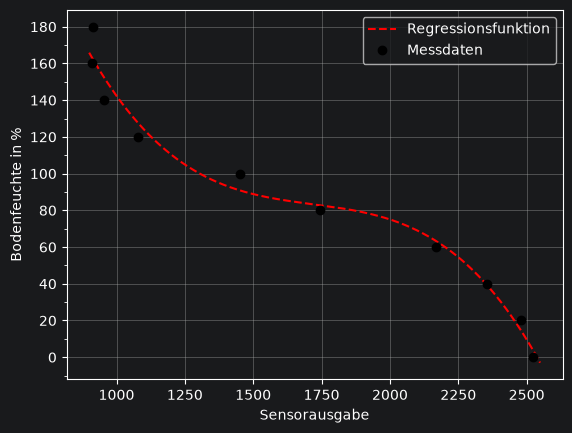

In [58]:
from scipy.optimize import curve_fit

sensor = pd.read_excel(DATA_DIR / 'Kalibrierung_Feuchtesensor.xlsx', sheet_name='v1.2_csv', index_col=0)
mittel = sensor.groupby(sensor.index)['Messwerte'].mean()

def func_sensor(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

rohwert = mittel.to_numpy()
moisture = mittel.index.to_numpy()
popt, _ = curve_fit(func_sensor, rohwert, moisture)

y = [func_sensor(i, *popt) for i in range(900, 2550)]

fig, ax = plt.subplots()

ax.plot(range(900, 2550), y, label='Regressionsfunktion', ls='--', c='r')
ax.plot(rohwert, moisture, label='Messdaten', ls='', marker='o', c='k')
ax.grid(True)
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(plt.MultipleLocator(20))
ax.set_xlabel('Sensorausgabe')
ax.set_ylabel('Bodenfeuchte in %')
ax.legend()
plt.show()

<a id="sec-1-3"></a>
## 1.3 Umgebungsdaten
Zur Datensammlung sollen auch die Umgebungstemperatur, -feuchte und -Druck gemessen werden. Hierzu wird ein Bosch BME280 eingesetzt. Dieser Sensor kann alle drei Werte messen. Die Messgenauigkeiten finden sich in Tabelle 1. Der Sensor kommuniziert mit dem ESP32 über eine $\mathrm{I^2C}$ Verbindung. Die Initialisierung der Sonsoren erfolgt dann über ein Skript in Micropython, welches auf den ESP32 geflasht wird.

<div align=center>
    <figure>
    <img src='Bilder/BME280.jpeg' alt='BME280' width='25%'> 
    <figcaption><i>Abb. 4: Platine mit BME280 Sensor</i></figcaption>
    </figure>
</div>

<div align="center">
    <b>Tab. 1: Messspezifikationen und Genauigkeiten des BME280 Sensors</b>
</div>

| Sensor-Parameter | Messbereich | Absolute Genauigkeit (Tolerance) | Relative Genauigkeit (Präzision) |
| :--- | :--- | :--- | :--- |
| **Luftdruck** | 300 ... 1100 hPa | $\pm$ 1,0 hPa (0 bis +65 °C) | $\pm$ 0,12 hPa |
| **Temperatur** | -40 ... +85 °C | $\pm$ 0,5 °C (bei 25 °C) | - |
| **Luftfeuchtigkeit** | 0 ... 100 % r.H. | $\pm$ 3 % relative Feuchte | -|

<a id="sec-1-3-1"></a>
#### 1.3.1 Wetterdaten API
Zur Datenabfrage wird eine API-Schnittstelle vom Wetterdienst **OpenWeather** genutzt und in den Code implementiert. Um eine Request an die API stellen zu können, muss auf der Webseite von [OpenWeather](https://openweathermap.org/api) ein API-Key angefordert werden. Für eine Anfrage wird das Python Paket ```requests``` verwendet.

In [59]:
import requests

Der eigentliche Aufruf wird über eine URL durchgeführt. Diese kann den [API Docs](https://openweathermap.org/api/one-call-4?collection=one_call_api#current) entnommen werden. In die URL werden die Koordinaten des gewünschten Standortes sowie ein gültiger API Key eingetragen. Die geographischen Koordinaten des Standortes wurden bei Google Earth entnommen. Die Längen- (Longitude) und Breitengrade (Latidude) mussten allerdings für die URL in Dezimalgrad umgerechnet werden mit folgender Formel: $$ DD = \text{Dezimalgrad} + \frac{\text{Minuten}}{60} + \frac{\text{Sekunden}}{3600} $$ Dazu wurde eine Funktion geschrieben die diese Umrechung übernimmt.

In [60]:
def gms_to_degree(degree, minutes, seconds, direction):
    '''
    Umrechung von 51°58'38.93"N zu Dezimalgrad für Longitude (Längengrad) und Latidude (Breitengrad)
    '''
    dd = float(degree) + float(minutes)/60 + float(seconds)/3600
    if direction in ['S', 'W']:
        dd *= -1
    return dd

So kann die Abfrage für die Wetterdaten durchgeführt werden

In [61]:
API_KEY = '957ce3f15b719431e622d38d78c397af'

lat_gms = (51, 58, 38.93, 'N') # Breitengrad als Gradminuten
lon_gms = (7, 33, 53.08, 'E') # Längengrad als Gradminuten

# Umrechung in Dezimalgrad
lat = gms_to_degree(*lat_gms)
lon = gms_to_degree(*lon_gms)

# Ausgabeeinheiten in metrische Einheiten festlegen
unit = 'metric' 

# Adresse zur Abfrage
url = f'https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units={unit}'

# Abrage über requests
response = requests.get(url) # erzeugt Responseobjekt mit der Antwort des Servers type -> <class 'requests.models.Response'>
data = response.json() # Server schickt Antwort als json. Hier wird die json decoded, type -> <class 'dict'>
print(data)

{'coord': {'lon': 7.5647, 'lat': 51.9775}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 18.73, 'feels_like': 18.72, 'temp_min': 17.81, 'temp_max': 18.73, 'pressure': 1010, 'humidity': 79, 'sea_level': 1010, 'grnd_level': 1004}, 'visibility': 10000, 'wind': {'speed': 5.66, 'deg': 210}, 'clouds': {'all': 69}, 'dt': 1787987319, 'sys': {'type': 2, 'id': 52688, 'country': 'DE', 'sunrise': 1787978190, 'sunset': 1788027926}, 'timezone': 7200, 'id': 2862632, 'name': 'Nienberge', 'cod': 200}


Das Objekt ```data``` von einer json in ein Dictionary umgewandelt. In diesem Dictionary sind jede Menge Informationen enthalten die wir in unserem Versuch nicht benötigen. Deshalb werden diese gefiltert, sodass nur relevante Daten zurückbleiben die dann in unsere übergeorndete CSV mit den Messdaten geschrieben werden können.

In [62]:
temp = data['main']['temp']
pressure = data['main']['pressure']
humidity = data['main']['humidity']

<a id="sec-1-4"></a>
## 1.4 Datenspeicherung
Wir speichern die Daten direkt auf dem ESP32. Beim Starten der Messung wird auf dem ESP32 ein Accesspoint erstellt. Somit ist es möglich sich über WLAN mit diesem zu verbinden. Um die Daten abzurufen ohne jedesmal die Messung unterbrechen und den ESP32 mit dem Computer verbinden zu müssen, werden die Daten auf einen Webserver hochgeladen und angezeigt. Mir einem Computer oder Smartphone können die Daten eingesehen werden und sich die bis dahin gefüllte CSV-Datei heruntergeladen werden.

<div align=center>
    <figure>
    <img src='Bilder/Webserver.png' alt='Webserver' width=50%>
    <figcaption><i>Abb. 5: Datenanzeige auf dem Webserver </i></figcaption>
    </figure>
</div>

Die Daten werden Temporär auf dem Arbeitsspeicher des ESP32 gespeichert. Um einen Datenverlust bei Stromausfall zu vermeiden werden die Daten viermal am Tag vom Arbeitsspeicher auf den dauerhaften Datenträger des gespeichert.

<a id="sec-2"></a>
# 2. Explorative Datenanalyse


In [63]:
# Datensatz einladen
data_raw = pd.read_csv(DATA_DIR / 'sensor_data.csv', sep=',', encoding='utf-8')

# Datetimeindex festlegen
format = '%Y-%m-%d %H:%M:%S'
data_raw['datetime'] = pd.to_datetime(data_raw['datetime'], format=format)
data_raw = data_raw.set_index('datetime')

<a id="sec-2-1"></a>
## 2.1 NaN-Werte behandeln
Wurde der Datensatz über den Webserver heruntergeladen, wurden dem Datensatz Datenlücken hinzugefügt bzw. einige Zeilen wurden mit leeren überschrieben. Für dieses Problem konnte vorerst keine Lösung gefunden werden. Deshalb wurde der Datensatz nur noch über direkte USB-Verbindung mit dem ESP32 heruntergeladen. Allerdings befinden sich nun im Datensatz einige Zeitstempel doppelt. Diese müssen gefilter und entfernt werden, da dem Dataframe sonst keine Frequenz hinzugefügt werden kann.

Da es Probleme bei der Datenerfassung gab, existiert zwischen dem 09.07. und 03.08. eine große Lücke. Diese wird bei ```.asfreq``` vorwärtsaufgefüllt.

In [64]:
delete_mask = (
    (data_raw.index.duplicated(keep=False)) &
    (data_raw.isna().any(axis=1))
)
data = data_raw[~delete_mask]

# Prbe wie viele NaN's übrig sind
data.isna().sum()

# Frequenz auf 15 min stellen
data = data.asfreq(freq='15min', method='ffill')

data.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 4819 entries, 2026-07-05 13:52:48 to 2026-08-24 18:22:48
Freq: 15min
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      4819 non-null   int64  
 1   humidity       4819 non-null   float64
 2   pressure       4819 non-null   float64
 3   pump_time      4819 non-null   float64
 4   soil_moisture  4819 non-null   float64
 5   temperature    4819 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 263.5 KB


Nachdem alle fehlerhaften Zeilen entfernt und die Frequenz festgelgt wurde, existieren keine NaN's mehr im Datensatz. Als nächstes können die Datenspalten visualisiert werden, um sich einen Überblick zu verschaffen. Die Spalte ```timestamp``` wird dabei erstmal vernachlässigt, da diese durch die Spalte ```datetime``` ersetzt wird.

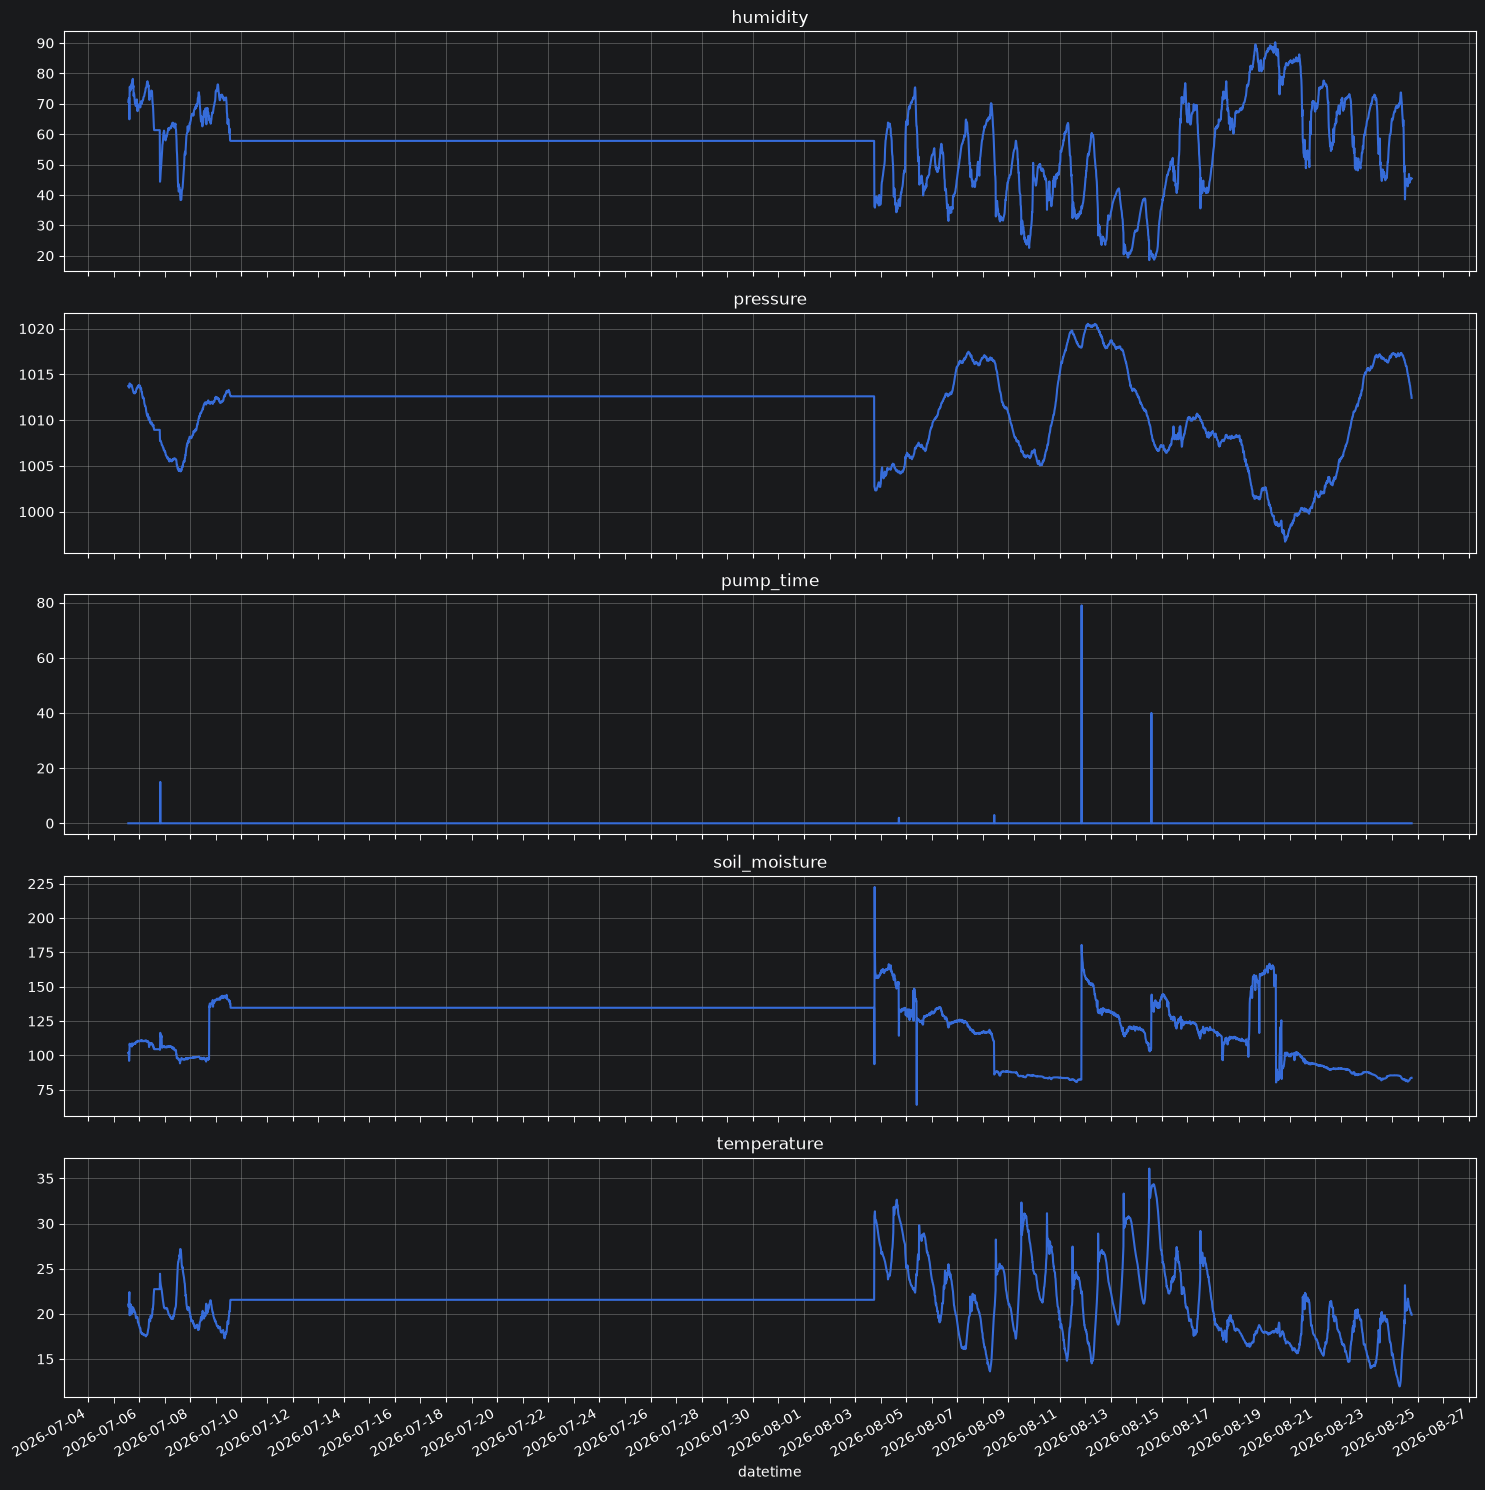

In [65]:
def plot_cols(df:pd.DataFrame, ignore= None):
    df_copy = df.copy()
    if isinstance(ignore, str):
        ignore = [ignore]

    if ignore:
        df = df_copy.drop(columns=ignore, errors='ignore')

    if len(df.columns) == 1:
        fig, ax = plt.subplots(figsize=(15, 3*len(df.columns)))
        df.plot(ax=ax)
        ax.set_title(df.columns[0])
        ax.grid(True)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
        ax.tick_params(axis='x', which='minor', length=4)
        fig.autofmt_xdate()
        fig.tight_layout()
        return

    fig, ax = plt.subplots(len(df.columns), 1, figsize=(15, 3*len(df.columns)), sharex=True)
    for ax, col in zip(ax, df.columns):
        ax = df[col].plot(ax = ax)
        ax.set_title(col)
        ax.grid(True)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
        ax.tick_params(axis='x', which='minor', length=4)

    fig.autofmt_xdate()
    fig.tight_layout()

plot_cols(data, ignore='timestamp')

Die Lücke wird hier deutlich über eine konstante Gerade in genannten Zeitraum. Zur besseren Sichtbarkeit wird die Betrachtung auf den rechten Bereich konzentriert und in einem neuen Dataframe ```data_aug``` gepeichert. Aus diesem werden dann alle Zeilen, in denen sich der gleiche Timestamp befindet entfernt.

Was in der Spalte ```soil_moisture``` auffällt ist, dass die Werte sich dauerhaft in einem Bereich außerhalb der festgelegten Hysterese bewegen. Hier sollten eigentlich Werte zwischen 50 und 80 % auftauchen. Warum die Werte so hoch ist nicht ganz klar und wird vorerst so hingenommen.

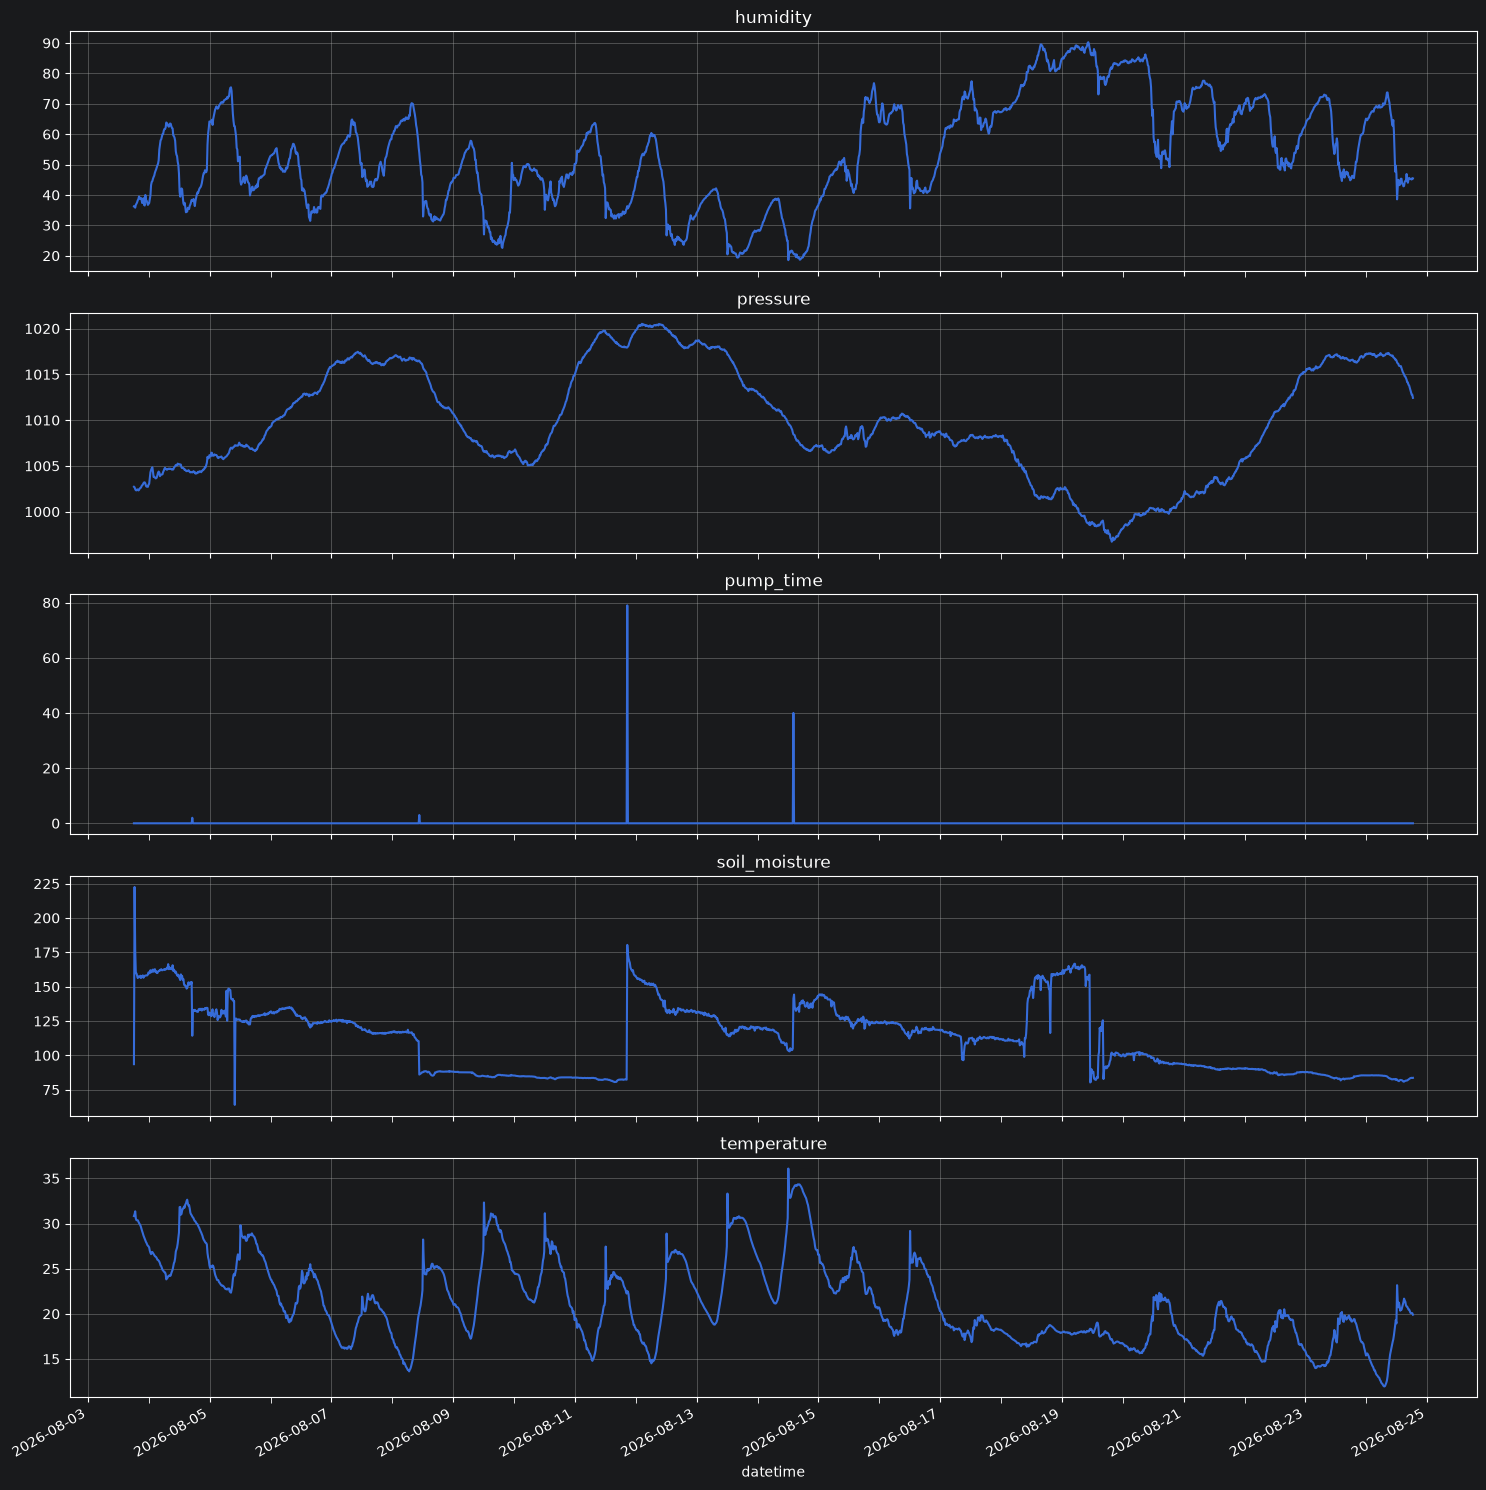

In [66]:
data_aug = data['2026-08-03':]
data_aug = data_aug[~data_aug.duplicated(keep=False)]

plot_cols(data_aug, ignore='timestamp')

<a id="sec-2-2"></a>
## 2.2 Zeitreihenanalyse


Zuerst soll ein gleitender Mittelwert für die ```soil_moisture``` erstellt werden, um den Trendverlauf besser zu erkennen und einzelne Sprünge herauszufiltern.

Beim gleitenden Mittelwert über vier Stunden erkennt man, dass die Spitzenwerte unter 80% und über 200 % einzelne Ausreißer waren. Außerdem erkennt man, dass die Kurve bei ```soil_moisture``` immer wieder kleine Anstiege hat, obwohl die Pumpe nicht läuft. Legt man die Daten für Boden- und Luftfeuchtigkeit übereinander, sieht man, dass an den Anstiegen die Luftfeuchtigkeit häufig ein lokales Maximum erreicht. Hier wird noch einmal ein durchschnittlicher Tagesverlauf der Feuchtigkeiten erstellt, um zu schauen ob sich die Tageszeitne überschneiden.

In [67]:
data_aug['soil_moisture_roll'] = data_aug['soil_moisture'].rolling('4h').mean()

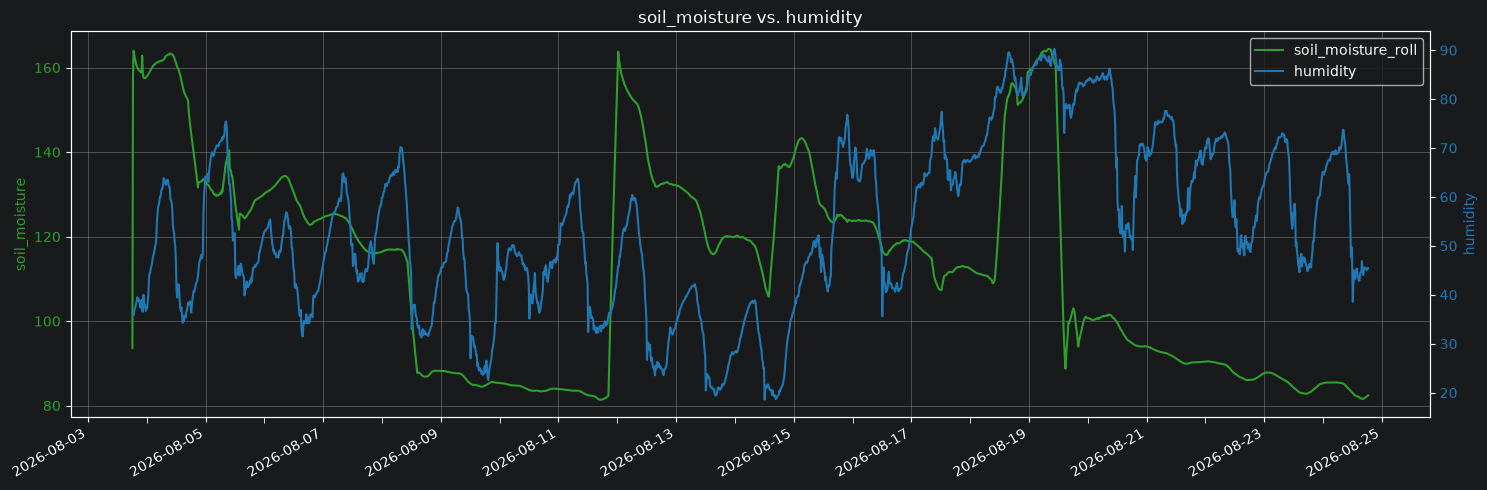

In [68]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(data_aug.index, data_aug['soil_moisture_roll'], color='tab:green', label='soil_moisture_roll')
ax1.set_ylabel('soil_moisture', color='tab:green')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.plot(data_aug.index, data_aug['humidity'], color='tab:blue', label='humidity')
ax2.set_ylabel('humidity', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax1.tick_params(axis='x', which='minor', length=4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('soil_moisture vs. humidity')
ax1.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Luftfeuchte in %')

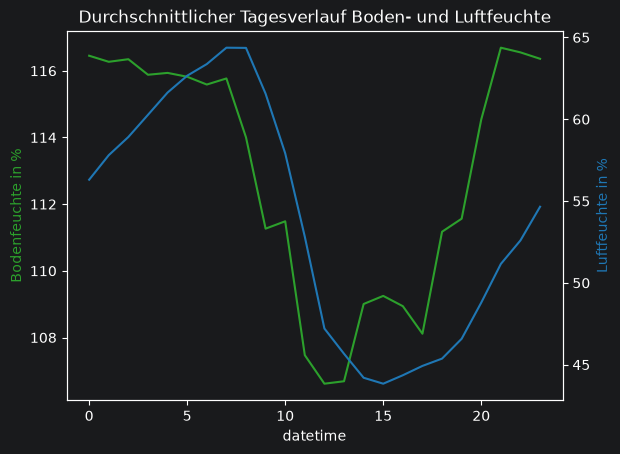

In [69]:
# Durchschnittlicher Tagesverlauf Feuchten
data_aug_soil = data_aug.groupby(data_aug.index.hour)['soil_moisture'].mean()
data_aug_hum = data_aug.groupby(data_aug.index.hour)['humidity'].mean()
data_aug_temp = data_aug.groupby(data_aug.index.hour)['temperature'].mean()
fig, ax = plt.subplots()
ax = data_aug_soil.plot(color='tab:green', label='soil_moisture', ax=ax)
ax2 = ax.twinx()
ax2 = data_aug_hum.plot(color='tab:blue', label='humidity', ax=ax2)
ax.set_title('Durchschnittlicher Tagesverlauf Boden- und Luftfeuchte')
ax.set_ylabel('Bodenfeuchte in %', color='tab:green')
ax2.set_ylabel('Luftfeuchte in %', color='tab:blue')


Man erkennt, dass die Verläufe der Boden- und Luftfeuchte recht ähnlich verlaufen. Fraglich ist die Ursache dieses Zusammenhangs. Es könnte sein, dass der Boden morgens bei hoher Luftfeuchtigkeit durch Kondensation Wasser aufnimmt. Allerdings steckte der Bodenfeuchtesensor mindestens 10 cm im Boden. Eine andere Möglichkeit könnte sein, dass der Sensor auf die Temperaturänderung reagiert. In der unteren Darstellung sieht man, dass es zu den Zeiten mit maximaler Bodenfeuchte auch die kühlsten Stunden des Tages sind. Da es sich um einen relativ günstigen Sensor handelt, könnte das eher die Ursache sein. Dies müsste aber mit einem Versuch genauer untersucht werden.

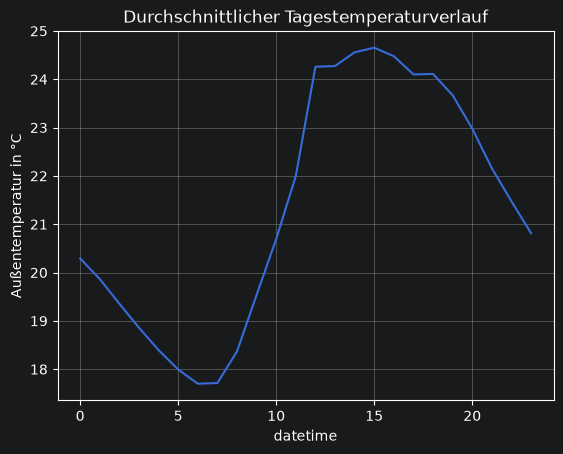

In [70]:
ax = data_aug_temp.plot()
ax.set_ylabel('Außentemperatur in °C')
ax.set_title('Durchschnittlicher Tagestemperaturverlauf')
ax.grid()

<a id="sec-2-2-1"></a>
### 2.2.1 Stationarität
Um die Zeitreihen auf Stationarität zu prüfen, wird für jede Variable ein Augmented-Dickey-Fuller-Test (`adfuller` aus `statsmodels.tsa.stattools`) durchgeführt. Der Test prüft, ob eine Reihe nicht-stationär ist (z. B. durch Trend oder einen sich verändernden Mittelwert). Liegt der p-Wert unter 0,05, gilt die Reihe als stationär.

In [71]:
for col in ['soil_moisture', 'temperature', 'humidity', 'pressure']:
    stat, p, *_ = adfuller(data_aug[col], result_object=True)
    print(f'{col}: ADF-Statistik = {stat:.3f}, p-Wert = {p:.4f}, '
          f'{"stationär" if p < 0.05 else "nicht stationär"}')

soil_moisture: ADF-Statistik = -2.843, p-Wert = 0.0524, nicht stationär
temperature: ADF-Statistik = -4.762, p-Wert = 0.0001, stationär
humidity: ADF-Statistik = -4.631, p-Wert = 0.0001, stationär
pressure: ADF-Statistik = -2.125, p-Wert = 0.2344, nicht stationär


Die Ergebnisse fallen gemischt aus: `temperature` und `humidity` sind mit p-Werten von jeweils 0,0001 eindeutig stationär, ihr Mittelwert schwankt im Beobachtungszeitraum also nicht systematisch. `soil_moisture` (p = 0,0524) und `pressure` (p = 0,2344) sind dagegen nicht stationär. Bei `soil_moisture` liegt der p-Wert nur knapp über der 5 %-Schwelle, was auf einen schwachen, aber vorhandenen Trend hindeutet – passend zu der bereits beobachteten dauerhaft hohen Bodenfeuchte, die sich eher langsam verändert, als um einen festen Mittelwert zu schwanken. Für `pressure` überrascht das Ergebnis wenig, da der Luftdruck über mehrere Wochen typischerweise wetterbedingten, längerfristigen Schwankungen unterliegt.

Für eine weiterführende Zeitreihenmodellierung (z. B. ARIMA) müssten `soil_moisture` und `pressure` entsprechend differenziert werden, um Stationarität herzustellen.

<a id="sec-2-2-2"></a>
### 2.2.2 Autokorrelation
Hier soll die soil_moisture untersucht werden. Wie stark hängt der aktuelle Wert der Bodenfeuchte von den Werten in früheren Zeitpunkten zusammen? Dazu werden Korrelationen des aktuellen Wertes mit den vorheringen berechnet. Mittels der Funktionen `plot_acs` und `plot_pacf` können diese Korrelationen visualisiert werden. Es wird hier mit 96 Lags gearbeitet, welche bei 15 min Schritten einem Tag entsprechen.

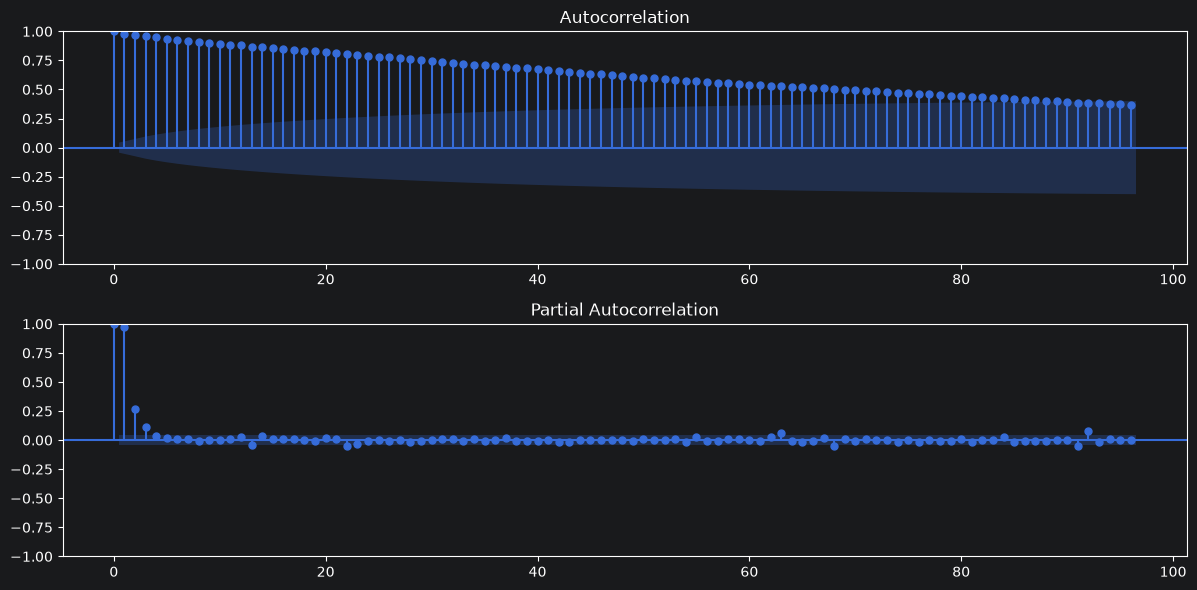

In [72]:
# ACF/PACF für soil_moisture, bis 96 Lags (= 1 Tag)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(data_aug['soil_moisture'], lags=96, ax=axes[0])
plot_pacf(data_aug['soil_moisture'], lags=96, ax=axes[1])
plt.tight_layout()

Bei der Autokorrelation scheint es so, dass ein Wert noch von Werten vor 8 Stunden stark beeinflusst wir. Um Auszuschließen, dass es sich dabei lediglich um indirekte Einflüsse handelt, wurde zusätzlich die partielle Autokorrelation berechnet. Diese zeigt, dass direkt nach dem zweiten Wert die Korrelation auf ca 0.25 absinkt. Das bedeutet, dass der aktuelle von den letzten zwei Werten direkt stark beeinflusst wird. Lag 3 und 4 haben korrelieren nur noch schwach miteinander. Für eine spätere Vorhersage der Bodenfeuchte sollten also die Werte der letzten 45 min bis eine Stunde herangezogen werden.

<a id="sec-2-3"></a>
## 2.3 Feature Engineering
Es sollen die letzten drei Lags vor jedem Bodenfeuchtewert als eigene Spalte in den Dataframe eingebracht werden. Das wird mit der Funktion `.shift` umgesetzt. Hierbei entstehen jeweils für die ersten drei Spalten NaN-Werte im Dataframe. Diese werden danach mit `.dropna` wieder entfernt.

In [73]:
for lag in [1, 2, 3]:
    data_aug[f'soil_moisture_lag{lag}'] = data_aug['soil_moisture'].shift(lag)

data_aug = data_aug.dropna(subset=['soil_moisture_lag1', 'soil_moisture_lag2', 'soil_moisture_lag3'])

Als weiteres Feature wird die Trocknungsrate ($\Delta$ soil_moisture) berechnet.

In [74]:
# Austrocknungsrate bestimmen
data_aug['soil_diff'] = data_aug['soil_moisture'].diff()

Damit im späteren Modell dei

In [75]:
# Stunde des Tages als sin/cos, damit 23:59 und 00:00 als "nah beieinander" erkannt werden
# (reine Ganzzahl 0-23 würde einen Sprung am Tageswechsel suggerieren)
hour = data_aug.index.hour + data_aug.index.minute / 60
data_aug['hour_sin'] = np.sin(2 * np.pi * hour / 24)
data_aug['hour_cos'] = np.cos(2 * np.pi * hour / 24)

Als weiteres Feature wird das sogenannte Vapour Pressure Deficite (VPD) aus Temperatur, Druck und rel. Feuchte berechnet. Das VPD bildet die Differenz aus dem Sättigungsdampfdruck von Wasserdampf bei der aktuellen Lufttemperatur und dem tatsächlichen Partialdruck des Wasserdampfes in der Luft. Das Ergebnis wird in kPa angegeben und beschreibt wie stark eine Verdunstung zu erwarten ist. Je höher die Differenz ist, desto schneller wird Wasser aus dem Beet verdunsten. $$ \text{VPD} = p_s - p_d $$ $p_s$ und $p_d$ werden mithilfe der CoolProp Bibliothek und der Funktion `HAPropsSI` berechnet.

In [76]:
from CoolProp.CoolProp import HAPropsSI

# Sättigungsdampf- und Partialdruck für jeden Timestep berechnen
def calc_pressure(df, saturated: bool = False)-> pd.Series:

    if not saturated:
        partial_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15, # Temperatur in Kelvin
                                'P', row['pressure'] * 100, # Pressure in Pa
                                'RH', row['humidity'] / 100), # humidity zwischen 0 und 1
                                axis=1)
        return partial_pressure

    else:

        saturated_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15,
                                'P', row['pressure'] * 100,
                                'RH', 1.0),
                                axis=1)
        return saturated_pressure


data_aug['partial_pressure'] = calc_pressure(data_aug, saturated=False)
data_aug['saturated_pressure'] = calc_pressure(data_aug, saturated=True)

# Berechnung des Sättigungsdefizits
def calc_VPD(df)-> pd.Series:
    '''VPD in kPa'''
    VPD = (df['saturated_pressure'] - df['partial_pressure']) / 1000

    return VPD

data_aug['VPD'] = calc_VPD(data_aug)


<a id="sec-3"></a>
# 3. Modellierung

Zuerst werden die Features und Zielgröße definiert und der Datensatz in Traings- und Testdaten aufgeteilt. Hier werden die Daten chronologisch gesplittet um sicherzustellen, dass die Reihenfolge der Zeitreihe nicht durcheinander gebracht wird.

Als Eingabegrößen für das Modell werden VPD, die Bodenfeuchte der letzten drei Zeitschritte (t-1, t-2, t-3) sowie eine zyklische Kodierung der Tageszeit verwendet. VPD soll den physikalischen Antrieb der Verdunstung abbilden, die vergangenen Bodenfeuchtewerte sollen dem Modell zusätzlich zeigen, wie sich der Boden zuletzt entwickelt hat. Trainiert werden zwei unterschiedliche Modelle, eine lineare Regression und ein Random Forest, um zu sehen, ob ein flexibleres Modell hier einen Vorteil gegenüber dem einfachen linearen Ansatz hat.

In [77]:
# Erweiterte Feature-Menge: VPD + Lags + zyklische Zeit
feature_cols = ['VPD', 'soil_moisture_lag1', 'soil_moisture_lag2',
                'soil_moisture_lag3']

ml_data = data_aug[data_aug['pump_time'] == 0][feature_cols + ['soil_diff']].dropna()

X = ml_data[feature_cols].to_numpy() # Numpy Array der Features, die zur Vorhersage dienen sollen
y = ml_data['soil_diff'].to_numpy() # Numpy Array der Spalte, welche vorhergesagt werden soll.

# chronologischer Split, damit Zeitreihe nicht durcheinander gebracht wird
split_idx = int(len(ml_data) * 0.8) # Split in Trainings- und Testdaten
X_train, X_test = X[:split_idx], X[split_idx:] # 80 % Trainingsdaten, 20 % Testdaten
y_train, y_test = y[:split_idx], y[split_idx:] # 80 % von soil_diff als Trainingsdaten, 20 % als Testdaten
test_index = ml_data.index[split_idx:]

Als erstes Modell wird eine lineare Regression durchgeführt. Diese wird mithilfe `LinearRegression()` aus sklearn durchgeführt. Als Kennzahlen für die Modellperformance werden das Betimmtheitsmaß $R^2$ und der Mean Squared Error (MSE) bestimmt. Zuvor werden die Features standardisiert mittels `StandardScaler`.

In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
data_aug['soil_diff']

datetime
2026-08-03 18:52:48     NaN
2026-08-03 19:07:48   -0.25
2026-08-03 19:22:48   -1.73
2026-08-03 19:37:48   -1.71
2026-08-03 19:52:48    1.22
                       ... 
2026-08-24 17:22:48    0.20
2026-08-24 17:37:48    0.11
2026-08-24 17:52:48    0.08
2026-08-24 18:07:48   -0.13
2026-08-24 18:22:48    0.09
Freq: 15min, Name: soil_diff, Length: 2015, dtype: float64

In [80]:
# Lineare Regression und RandomForest ausprobieren
# models = {
#     'Lineare Regression': LinearRegression(),
#     'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42), # Hier evtl. später Hyperparametertuning durchführen
# }
#
# for name, model in models.items(): # Iteration über die Modelle
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     print(name, 'R2:', round(r2_score(y_test, y_pred), 4),
#           'MAE:', round(mean_absolute_error(y_test, y_pred), 4))
LinReg = LinearRegression()
LinReg.fit(X_train_scaled, y_train)
Lin_y_pred = LinReg.predict(X_test_scaled)
r2_LinReg = r2_score(y_test, Lin_y_pred)
mse_LinReg = mean_squared_error(y_test, Lin_y_pred)
print(f'Lineare Regression\n\
R2-Score = {r2_LinReg:.3f}, MSE = {mse_LinReg:.3f}, MAE = {mean_absolute_error(y_test, Lin_y_pred):.3f}')

Lineare Regression
R2-Score = -0.574, MSE = 0.160, MAE = 0.307




Die Ergebnisse des $R^2$ zeigen allerdings, dass das Modell keine gute Vorhersage machen kann. Das negative Bestimmtheitsmaß sagt aus, das die Vorhersage unzutreffender ist als der reine Mittelwert der Daten. Außerdem sind die MSE und MAE auch sehr hoch, wenn man bedenkt, dass `soil_diff` sich größtenteils im Bereich zwischen 0 und 1 bewegt.

Als Nächstes wird ein RandomForestRegressor ausprobiert. Hierbei werden die nicht skalierten Daten verwendet.

In [81]:
RandomForest = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=4)
RandomForest.fit(X_train, y_train)
RandomForest_y_pred = RandomForest.predict(X_test)
r2_RandomForest = r2_score(y_test, RandomForest_y_pred)
mse_RandomForest = mean_squared_error(y_test, RandomForest_y_pred)
print(f'RandomForest Regression\n\
R2-Score = {r2_RandomForest:.3f}, MSE = {mse_RandomForest:.3f}, MAE = {mean_absolute_error(y_test, RandomForest_y_pred):.3f}')

RandomForest Regression
R2-Score = -0.468, MSE = 0.149, MAE = 0.263


Auch hier ergeben sich ähnlich schlechte Werte aus der Vorhersage. Das Ganze wird im folgenden noch einmal visualisiert.

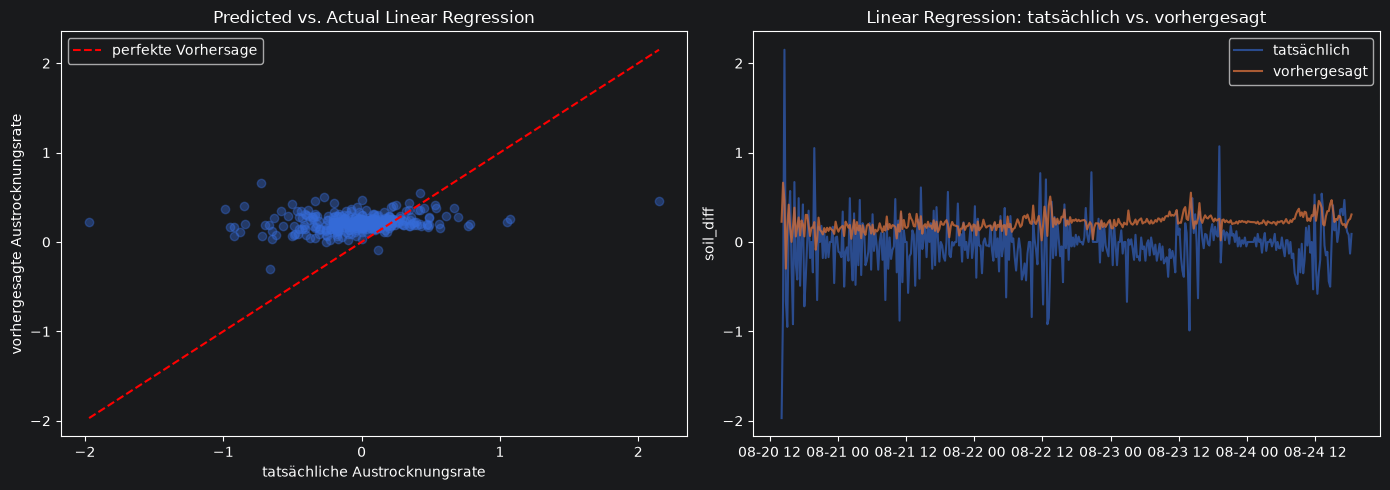

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Predicted vs. Actual ---
# Perfekte Vorhersage läge exakt auf der Diagonalen (rot gestrichelt)
axes[0].scatter(y_test, Lin_y_pred, alpha=0.4)
lims = [min(y_test.min(), Lin_y_pred.min()), max(y_test.max(), Lin_y_pred.max())]
axes[0].plot(lims, lims, 'r--', label='perfekte Vorhersage')
axes[0].set_xlabel('tatsächliche Austrocknungsrate')
axes[0].set_ylabel('vorhergesagte Austrocknungsrate')
axes[0].legend()
axes[0].set_title('Predicted vs. Actual Linear Regression')

# --- 2. Zeitverlauf im Testzeitraum ---
# Zeigt, ob das Modell die Schwankungen über die Zeit überhaupt trifft
axes[1].plot(test_index, y_test, label='tatsächlich', alpha=0.6)
axes[1].plot(test_index, Lin_y_pred, label='vorhergesagt', alpha=0.8)
axes[1].set_ylabel('soil_diff')
axes[1].legend()
axes[1].set_title('Linear Regression: tatsächlich vs. vorhergesagt')

plt.tight_layout()
plt.show()

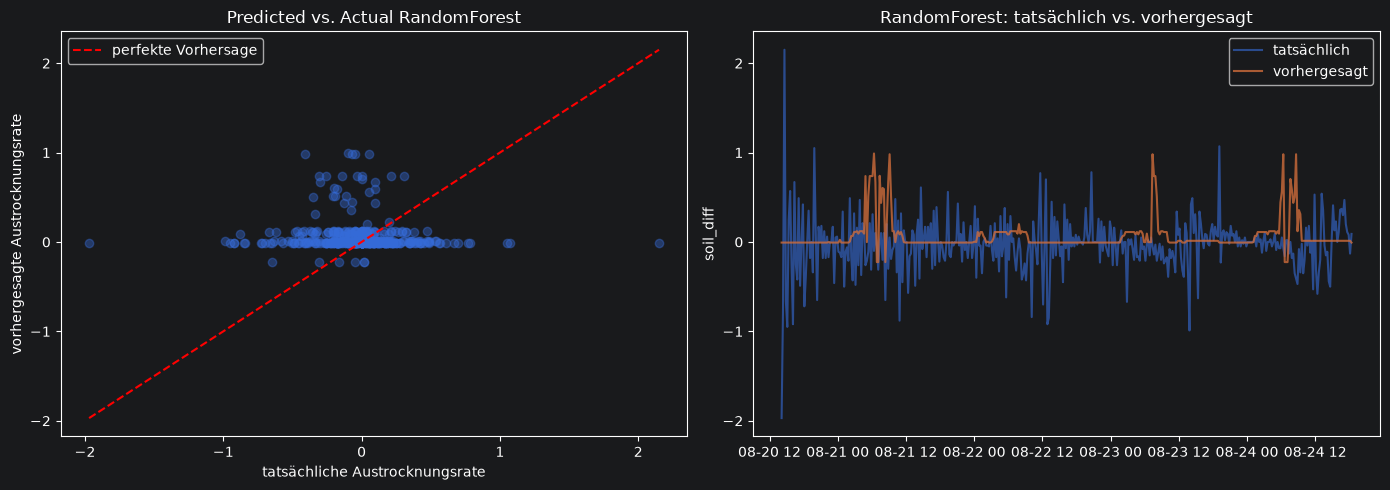

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Predicted vs. Actual ---
# Perfekte Vorhersage läge exakt auf der Diagonalen (rot gestrichelt)
axes[0].scatter(y_test, RandomForest_y_pred, alpha=0.4)
lims = [min(y_test.min(), RandomForest_y_pred.min()), max(y_test.max(), RandomForest_y_pred.max())]
axes[0].plot(lims, lims, 'r--', label='perfekte Vorhersage')
axes[0].set_xlabel('tatsächliche Austrocknungsrate')
axes[0].set_ylabel('vorhergesagte Austrocknungsrate')
axes[0].legend()
axes[0].set_title('Predicted vs. Actual RandomForest')

# --- 2. Zeitverlauf im Testzeitraum ---
# Zeigt, ob das Modell die Schwankungen über die Zeit überhaupt trifft
axes[1].plot(test_index, y_test, label='tatsächlich', alpha=0.6)
axes[1].plot(test_index, RandomForest_y_pred, label='vorhergesagt', alpha=0.8)
axes[1].set_ylabel('soil_diff')
axes[1].legend()
axes[1].set_title('RandomForest: tatsächlich vs. vorhergesagt')

plt.tight_layout()
plt.show()

Der linke Plot zeigt die Vorhersage gegen den tatsächlichen Wert der Austrocknungsrate. Läge das Modell richtig, müssten die Punkte auf der roten gestrichelten Diagonalen liegen. Stattdessen streuen sie relativ wahllos um die Diagonale, was zeigt, dass das Modell die tatsächlichen Werte nicht gut trifft. Der rechte Plot zeigt denselben Sachverhalt über die Zeit: die tatsächliche Austrocknungsrate schwankt sichtbar, während die Vorhersage des Modells deutlich flacher verläuft und sich kaum an diese Schwankungen anpasst. Das Modell scheint also eher in Richtung eines groben Mittelwerts zu tendieren, statt die tatsächliche Dynamik abzubilden, was zu den bereits negativen R²-Werten passt.

Die Vorhersage der linearen Regression erfasst zumindest eine gewisse Dynamik und schwankt periodisch. Es sieht zumindest, die Schwankung der Austrockung, allerdings trifft es die tatsächlichen Werte auch nicht sehr präzise.

<a id="sec-3-1"></a>
## 3.1 Hyperparametertuning
Als weiterer Versuch sollen die Hyperparameter des RandomForestRegressor noch optimiert werden, um eine schlechte Modellwahl auszuschließen. Dabei wird mit GridSearchCV gearbeitet, welches alle Kombinationen an Hyperparametern durchgeht. Da hier der Datensatz nicht zu groß sollte das zeitlich gut möglich sein.

In [84]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Voller Parameterraum, da GridSearchCV alle Kombinationen prüft (Daten sind klein genug, dass das zeitlich kein Problem ist)
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300, 400],
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20, 30],
    'max_features': ['sqrt', 'log2', None],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,          # 7*8*7*3=1176 Kombinationen x 5 CV-Folds = 5880 Trainingsläufe
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print('Beste Parameter:', grid_search.best_params_)
print('Bester CV-R2 (Training):', grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_rs = best_model.predict(X_test)
print('Test R2:', r2_score(y_test, y_pred_rs))
print('Test MAE:', mean_absolute_error(y_test, y_pred_rs))

Beste Parameter: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'n_estimators': 250}
Bester CV-R2 (Training): -1.0510685579229733
Test R2: -0.3493512918367663
Test MAE: 0.2506877628395042


Die GridSearch läuft ca. vier Minuten auf dem aktuellen Rechner. Liefert allerdings keine wirkliche Verbesserung.

In [85]:
from datetime import datetime

dt = int(datetime(2026, 8, 3, 0).timestamp())

url_history = f'https://api.openweathermap.org/data/3.0/onecall/timemachine?lat={lat}&lon={lon}&dt={dt}&appid={API_KEY}'

response = requests.get(url_history)
weather_history = response.json()
print(weather_history)

{'lat': 51.9775, 'lon': 7.5647, 'timezone': 'Europe/Berlin', 'timezone_offset': 7200, 'data': [{'dt': 1785708000, 'sunrise': 1785729263, 'sunset': 1785784645, 'temp': 293.96, 'feels_like': 293.35, 'pressure': 1016, 'humidity': 48, 'dew_point': 282.56, 'clouds': 61, 'wind_speed': 4.27, 'wind_deg': 81, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}]}]}
